# 🌸 Iris Flower Classification using Machine Learning

## Data Science Internship — Week 4

**Organization:** SystemTron  
**Team:** SystemTron  
**Project:** Iris Flower Classification  
**Week:** 4

---

## Internship Task

The Iris flower dataset consists of three species:

- Setosa
- Versicolor
- Virginica

These species can be distinguished based on their sepal and petal measurements.

The objective of this project is to train a machine learning model that can learn from these measurements and accurately classify Iris flowers into their respective species.

### Objective

Develop a machine learning classification model that predicts the species of an Iris flower based on:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

### Machine Learning Problem

This project is a **supervised multiclass classification problem**.

**Features:**
- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

**Target:**
- Iris Species

### Dataset

The dataset is provided by the internship task through Kaggle:

**Iris Flower Dataset**

The dataset contains observations belonging to three Iris species:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

## 1. Import Required Libraries

The project uses Python libraries for:

- Data manipulation
- Data visualization
- Dataset downloading
- Machine learning
- Model evaluation

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# File and system handling
from pathlib import Path
import os
import zipfile
import urllib.request

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Download the Iris Dataset

The Iris dataset is provided by the SystemTron internship task through Kaggle.

The dataset is downloaded programmatically and stored inside the project's `data/raw` directory.

This keeps the project reproducible and avoids manually downloading files.

In [2]:
# Resolve the project root from either the repository root or notebooks/
def resolve_project_root():
    for candidate in (Path.cwd(), Path.cwd().parent):
        required_directories = ("data", "notebooks", "reports", "results", "models")
        if all((candidate / directory).is_dir() for directory in required_directories):
            return candidate
    raise FileNotFoundError("Project root containing data/, notebooks/, reports/, results/, and models/ was not found.")

project_root = resolve_project_root()

raw_path = project_root / "data" / "raw"
raw_path.mkdir(parents=True, exist_ok=True)

# Kaggle dataset download URL
kaggle_url = "https://www.kaggle.com/api/v1/datasets/download/arshid/iris-flower-dataset"

# ZIP file location
zip_path = raw_path / "iris-flower-dataset.zip"

# Download dataset
urllib.request.urlretrieve(kaggle_url, zip_path)

print("Dataset downloaded successfully!")
print("Downloaded file:", zip_path)

Dataset downloaded successfully!
Downloaded file: d:\system tron intership\data science inter\Iris_Flower_Classification_Week_4\data\raw\iris-flower-dataset.zip


In [3]:
# Extract the downloaded ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(raw_path)

print("Dataset extracted successfully!")

# Display extracted files
print("\nFiles in raw folder:")
for file in raw_path.iterdir():
    print(file.name)

Dataset extracted successfully!

Files in raw folder:
iris-flower-dataset.zip
IRIS.csv


In [4]:
# Find CSV files in the raw folder
csv_files = list(raw_path.glob("*.csv"))

print("CSV files found:")

for file in csv_files:
    print(file.name)

CSV files found:
IRIS.csv


In [5]:
# Verify the downloaded Kaggle dataset

dataset_file = raw_path / "IRIS.csv"

if dataset_file.exists():
    print("Kaggle Iris dataset verified successfully!")
    print("Dataset location:", dataset_file)
    print("File size:", round(dataset_file.stat().st_size / 1024, 2), "KB")
else:
    print("Dataset file not found.")

Kaggle Iris dataset verified successfully!
Dataset location: d:\system tron intership\data science inter\Iris_Flower_Classification_Week_4\data\raw\IRIS.csv
File size: 4.51 KB


## 3. Load the Iris Dataset

The Iris dataset provided by the SystemTron internship task has been downloaded from Kaggle and stored in the project's `data/raw` directory.

The dataset will now be loaded into a Pandas DataFrame for further analysis and machine learning.

The dataset contains measurements of Iris flowers belonging to three species:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

In [6]:
# Path to the Kaggle Iris dataset
dataset_file = raw_path / "IRIS.csv"

# Load the dataset
df = pd.read_csv(dataset_file)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [7]:
print("Dataset Columns:")
print(df.columns.tolist())

Dataset Columns:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [8]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [9]:
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


## 4. Data Understanding

Before performing data cleaning and building machine learning models, the structure and quality of the Iris dataset are examined.

The following aspects are analyzed:

- Dataset dimensions
- Feature names
- Data types
- Statistical summary
- Missing values
- Duplicate records

This helps identify the characteristics and quality of the dataset before preprocessing.

4.1 Dataset Dimensions

In [10]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("Dataset Shape:", df.shape)

Number of Rows: 150
Number of Columns: 5
Dataset Shape: (150, 5)


4.2 Feature Names

In [11]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


4.3 Data Types

In [12]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


4.4 Statistical Summary

In [13]:
print("Statistical Summary:")
df.describe().T

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
sepal_length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal_width,150.0,3.054000,0.433594,2.0,2.8,3.00,3.3,4.4
petal_length,150.0,3.758667,1.764420,1.0,1.6,4.35,5.1,6.9
petal_width,150.0,1.198667,0.763161,0.1,0.3,1.30,1.8,2.5


4.5 Missing Values

In [14]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


4.6 Duplicate Records

In [15]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 3


## 5. Data Cleaning & Feature Engineering

The data understanding stage identified three duplicate records and no missing values in the dataset.

In this stage, the dataset is prepared for exploratory analysis and machine learning.

The following preprocessing steps are performed:

- Handle missing values
- Remove duplicate records
- Verify data types
- Encode the target variable
- Separate features and target variables
- Save the cleaned dataset for further analysis

5.1 Handle Missing Values

In [16]:
# Check total missing values
missing_values = df.isnull().sum().sum()

print("Total Missing Values:", missing_values)

if missing_values == 0:
    print("No missing values found. Dataset is ready for the next cleaning step.")
else:
    print("Missing values detected. Further handling is required.")

Total Missing Values: 0
No missing values found. Dataset is ready for the next cleaning step.


### 5.2 Remove Duplicate Records

The dataset contains duplicate records that can affect the analysis and machine learning model.

The duplicate records are identified and removed to ensure that each observation is represented only once.

In [17]:
# Count duplicates before removal
duplicates_before = df.duplicated().sum()

print("Duplicate records before cleaning:", duplicates_before)

# Remove duplicate records
df = df.drop_duplicates().reset_index(drop=True)

# Count duplicates after removal
duplicates_after = df.duplicated().sum()

print("Duplicate records after cleaning:", duplicates_after)
print("Dataset Shape after removing duplicates:", df.shape)

Duplicate records before cleaning: 3
Duplicate records after cleaning: 0
Dataset Shape after removing duplicates: (147, 5)


### 5.3 Verify Data Types

After removing duplicate records, the data types of all columns are verified to ensure that the numerical features are suitable for machine learning.

The four measurement features should be numerical, while the species column should contain categorical values.

In [18]:
# Check data types after cleaning
print("Data Types After Cleaning:")
print(df.dtypes)

Data Types After Cleaning:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


In [19]:
# Verify the data types
print("Numerical Features:")
print(df.select_dtypes(include=["number"]).columns.tolist())

print("\nCategorical Features:")
print(df.select_dtypes(include=["object", "string", "category"]).columns.tolist())

Numerical Features:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

Categorical Features:
['species']


### 5.4 Encode the Target Variable

The `species` column contains categorical labels representing the three Iris species.

For machine learning, these categorical labels are encoded into numerical values using `LabelEncoder`.

The encoding allows the model to work with the target variable while preserving the three-class classification problem.

In [20]:
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode species
df["species_encoded"] = label_encoder.fit_transform(df["species"])

# Display the encoding mapping
print("Species Encoding:")

for species, encoded_value in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(f"{species} → {encoded_value}")

Species Encoding:
Iris-setosa → 0
Iris-versicolor → 1
Iris-virginica → 2


In [21]:
df[["species", "species_encoded"]].drop_duplicates().sort_values("species_encoded")

,species,species_encoded
0,Iris-setosa,0
48,Iris-versicolor,1
98,Iris-virginica,2


### 5.5 Separate Features and Target

The dataset is divided into input features and the target variable.

The four sepal and petal measurements are used as input features, while the encoded species labels are used as the target variable.

**Features (X):**
- sepal_length
- sepal_width
- petal_length
- petal_width

**Target (y):**
- species_encoded

In [22]:
# Define input features
X = df[
    [
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ]
]

# Define target variable
y = df["species_encoded"]

print("Features (X):")
print(X.columns.tolist())

print("\nTarget (y):")
print(y.name)

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)

Features (X):
['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

Target (y):
species_encoded

Feature Shape: (147, 4)
Target Shape: (147,)


### 5.6 Save the Processed Dataset

The cleaned dataset is saved in the `data/processed` directory.

The processed dataset contains the original Iris measurements, the original species labels, and the encoded target variable.

Saving the processed dataset allows the cleaned data to be reused during exploratory data analysis and model development.

In [23]:
# Create processed data directory
processed_path = project_root / "data" / "processed"
processed_path.mkdir(parents=True, exist_ok=True)

# Define processed dataset file
processed_file = processed_path / "iris_dataset_cleaned.csv"

# Save cleaned dataset
df.to_csv(processed_file, index=False)

print("Processed dataset saved successfully!")
print("Location:", processed_file)
print("Processed Dataset Shape:", df.shape)

Processed dataset saved successfully!
Location: d:\system tron intership\data science inter\Iris_Flower_Classification_Week_4\data\processed\iris_dataset_cleaned.csv
Processed Dataset Shape: (147, 6)


In [24]:
# Verify processed dataset
if processed_file.exists():
    print("Processed CSV verified successfully!")
    print("File size:", round(processed_file.stat().st_size / 1024, 2), "KB")
else:
    print("Processed CSV was not found.")

Processed CSV verified successfully!
File size: 4.86 KB


## 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distribution and relationships between the Iris flower measurements and species.

The following visualizations are used:

- Species distribution
- Feature distributions
- Feature comparison using boxplots
- Pairwise relationships between features
- Correlation analysis

These visualizations help identify patterns and determine which measurements may be useful for classifying Iris flower species.

### 6.1 Species Distribution

The distribution of the three Iris species is analyzed to determine the number of observations belonging to each class.

A count plot is used to visualize the species distribution.

The visualization is saved in the `results` directory.

In [25]:
from pathlib import Path

# Resolve the project root for executions started from the repository root or notebooks/
project_root = resolve_project_root()

# Create results directory
results_path = project_root / "results"
results_path.mkdir(parents=True, exist_ok=True)

print("Results directory ready!")
print("Location:", results_path)

Results directory ready!
Location: d:\system tron intership\data science inter\Iris_Flower_Classification_Week_4\results


Species Distribution:
species
Iris-versicolor    50
Iris-virginica     49
Iris-setosa        48
Name: count, dtype: int64


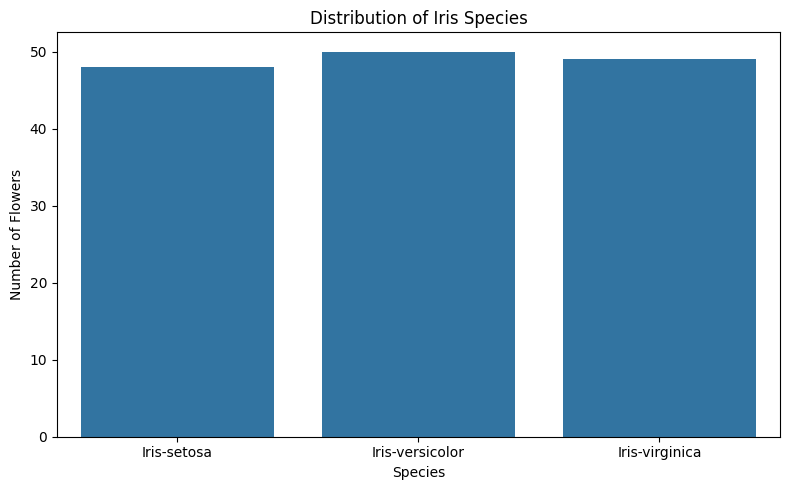

Plot saved successfully!
Location: d:\system tron intership\data science inter\Iris_Flower_Classification_Week_4\results\01_species_distribution.png


In [26]:
# Count species
species_counts = df["species"].value_counts()

print("Species Distribution:")
print(species_counts)

# Create one chart
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="species"
)

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Number of Flowers")

plt.tight_layout()

# Save
species_plot = results_path / "01_species_distribution.png"

plt.savefig(
    species_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Plot saved successfully!")
print("Location:", species_plot)

### 6.2 Feature Distribution — Petal Length

The distribution of petal length is analyzed to understand its range and frequency across the Iris dataset.

A histogram is used to visualize the distribution of petal length.

The visualization is saved in the `results` directory.

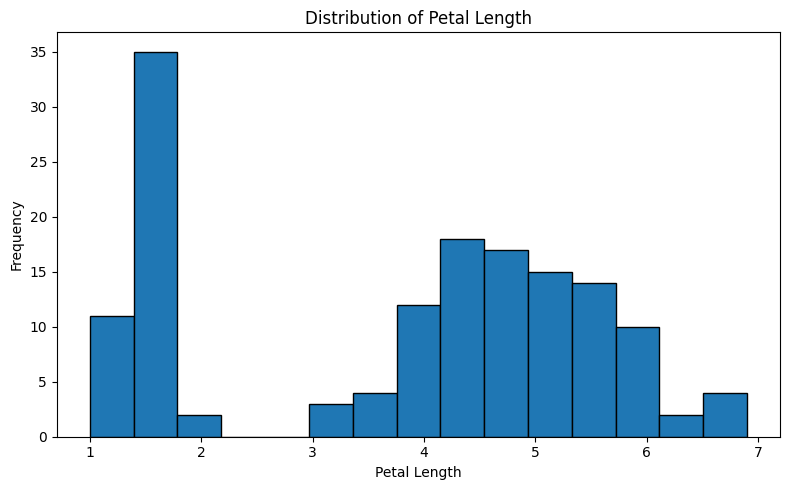

Plot saved successfully!
Location: d:\system tron intership\data science inter\Iris_Flower_Classification_Week_4\results\02_feature_distribution.png


In [27]:
# Create one histogram
plt.figure(figsize=(8, 5))

plt.hist(
    df["petal_length"],
    bins=15,
    edgecolor="black"
)

plt.title("Distribution of Petal Length")
plt.xlabel("Petal Length")
plt.ylabel("Frequency")

plt.tight_layout()

# Save
feature_distribution_file = results_path / "02_feature_distribution.png"

plt.savefig(
    feature_distribution_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Plot saved successfully!")
print("Location:", feature_distribution_file)

### 6.3 Feature Comparison — Petal Length

The distribution of petal length is compared across the three Iris species.

A boxplot is used to examine differences in petal length between species and identify potential outliers.

The visualization is saved in the `results` directory.

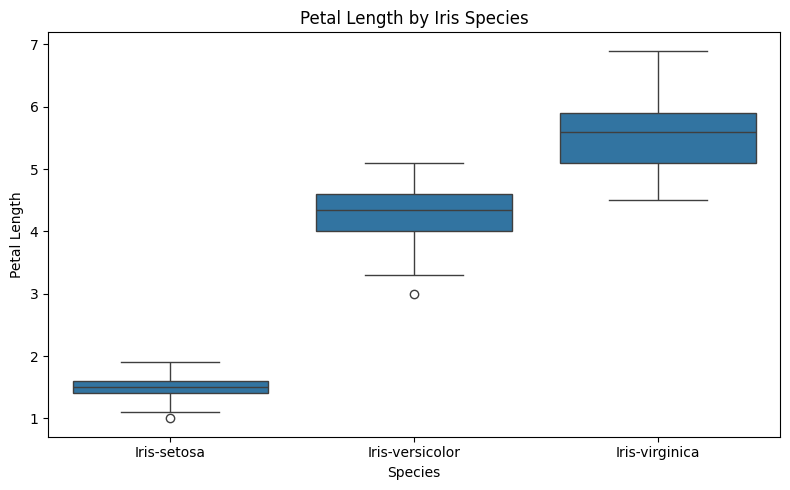

Plot saved successfully!
Location: d:\system tron intership\data science inter\Iris_Flower_Classification_Week_4\results\03_petal_length_boxplot.png


In [28]:
# Create one boxplot
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="species",
    y="petal_length"
)

plt.title("Petal Length by Iris Species")
plt.xlabel("Species")
plt.ylabel("Petal Length")

plt.tight_layout()

# Save
boxplot_file = results_path / "03_petal_length_boxplot.png"

plt.savefig(
    boxplot_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Plot saved successfully!")
print("Location:", boxplot_file)

### 6.4 Petal Length vs Petal Width

A scatter plot is used to examine the relationship between petal length and petal width across the three Iris species.

This visualization helps identify whether these two features provide clear separation between the species.

The visualization is saved in the `results` directory.

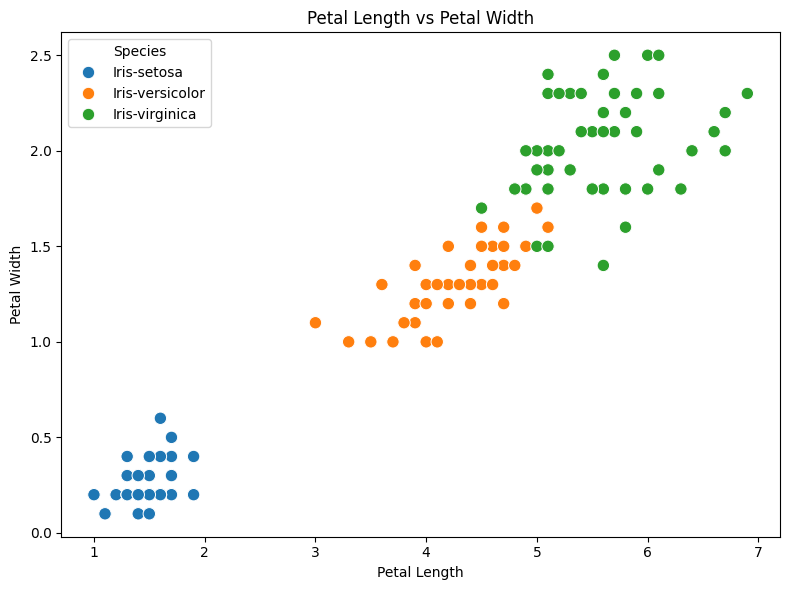

Plot saved successfully!
Location: d:\system tron intership\data science inter\Iris_Flower_Classification_Week_4\results\04_petal_length_vs_width.png


In [29]:
# Create scatter plot
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="petal_length",
    y="petal_width",
    hue="species",
    s=80
)

plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.legend(title="Species")

plt.tight_layout()

# Save visualization
scatter_file = results_path / "04_petal_length_vs_width.png"

plt.savefig(
    scatter_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Plot saved successfully!")
print("Location:", scatter_file)

### 6.5 Correlation Analysis

Correlation analysis is performed to understand the relationships between the numerical features of the Iris dataset.

A correlation heatmap is used to visualize the strength and direction of relationships between:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

The correlation values range from -1 to +1, where values closer to +1 indicate a strong positive relationship and values closer to -1 indicate a strong negative relationship.

The heatmap is saved in the `results` directory.

Correlation Matrix:


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109321,0.871305,0.817058
sepal_width,-0.109321,1.000000,-0.421057,-0.356376
petal_length,0.871305,-0.421057,1.000000,0.961883
petal_width,0.817058,-0.356376,0.961883,1.000000


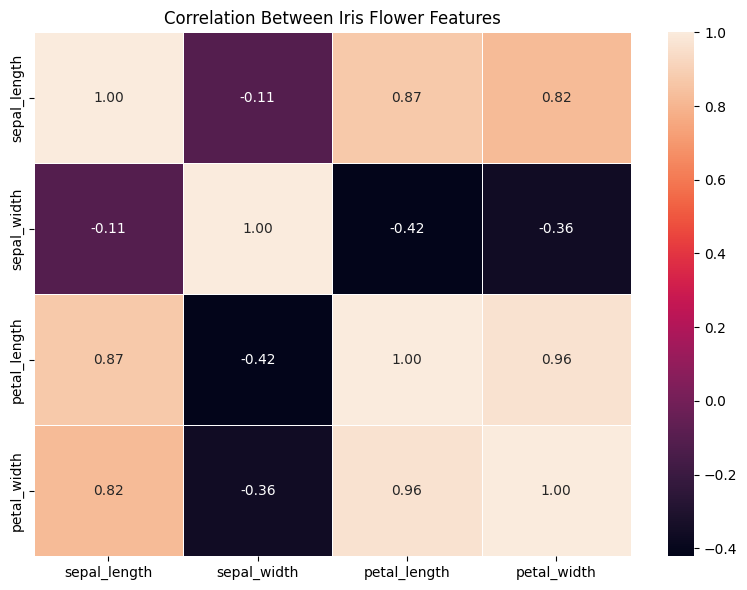

Plot saved successfully!
Location: d:\system tron intership\data science inter\Iris_Flower_Classification_Week_4\results\05_correlation_heatmap.png


In [30]:
# Select numerical features
numerical_features = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]

# Calculate correlation matrix
correlation_matrix = df[numerical_features].corr()

print("Correlation Matrix:")
display(correlation_matrix)

# Create one heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Between Iris Flower Features")

plt.tight_layout()

# Save visualization
correlation_file = results_path / "05_correlation_heatmap.png"

plt.savefig(
    correlation_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Plot saved successfully!")
print("Location:", correlation_file)

### 6.6 EDA Key Findings

The exploratory data analysis produced the following observations:

- The three Iris species are represented in the dataset with a relatively balanced distribution.
- Petal length shows noticeable variation across the dataset.
- Petal length differs considerably between the three Iris species.
- Petal length and petal width show a strong relationship and provide useful information for distinguishing Iris species.
- The correlation analysis indicates that petal-related measurements have strong positive relationships with each other.
- The observed feature patterns suggest that the Iris species can be effectively classified using their sepal and petal measurements.

## 7. Train-Test Split

The cleaned Iris dataset is divided into training and testing sets before developing the machine learning models.

An 80:20 split is used:

- **80% Training Data:** Used to train the machine learning models.
- **20% Testing Data:** Used to evaluate the models on unseen data.

Stratified sampling is used to maintain a similar distribution of Iris species in both the training and testing datasets.

In [31]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train-Test Split Completed!")

print("\nTraining Data:")
print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)

print("\nTesting Data:")
print("X_test Shape:", X_test.shape)
print("y_test Shape:", y_test.shape)

Train-Test Split Completed!

Training Data:
X_train Shape: (117, 4)
y_train Shape: (117,)

Testing Data:
X_test Shape: (30, 4)
y_test Shape: (30,)


In [32]:
print("Training Target Distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting Target Distribution:")
print(y_test.value_counts().sort_index())

Training Target Distribution:
species_encoded
0    38
1    40
2    39
Name: count, dtype: int64

Testing Target Distribution:
species_encoded
0    10
1    10
2    10
Name: count, dtype: int64


### 7.1 Verify Train-Test Split

The training and testing datasets are verified to ensure that the split was performed correctly and that no records were lost during the process.

In [33]:
# Verify dataset split
total_records = len(X_train) + len(X_test)

print("Original Cleaned Records:", len(X))
print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))
print("Total After Split:", total_records)

if total_records == len(X):
    print("\nTrain-test split verified successfully!")
else:
    print("\nError: Records do not match.")

Original Cleaned Records: 147
Training Records: 117
Testing Records: 30
Total After Split: 147

Train-test split verified successfully!


## 8. Model Training

Multiple supervised machine learning classification algorithms are trained to classify Iris flowers into their respective species.

The following models are developed and compared:

1. Decision Tree Classifier
2. Random Forest Classifier
3. K-Nearest Neighbors (KNN)

The models are trained using the training dataset and evaluated using the unseen testing dataset.

### 8.1 Decision Tree Classifier

A Decision Tree Classifier is trained to classify Iris flowers based on their sepal and petal measurements.

The model learns decision rules from the training data and uses these rules to predict the species of unseen Iris flowers.

In [34]:
# Create Decision Tree model
decision_tree = DecisionTreeClassifier(
    random_state=42
)

# Train the model
decision_tree.fit(X_train, y_train)

# Make predictions
dt_predictions = decision_tree.predict(X_test)

print("Decision Tree model trained successfully!")
print("Predictions generated:", len(dt_predictions))

Decision Tree model trained successfully!
Predictions generated: 30


### 8.2 Random Forest Classifier

A Random Forest Classifier is trained using multiple decision trees.

The model combines the predictions of multiple trees to improve classification performance and reduce the risk of overfitting.

In [35]:
# Create Random Forest model
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest.fit(X_train, y_train)

# Make predictions
rf_predictions = random_forest.predict(X_test)

print("Random Forest model trained successfully!")
print("Predictions generated:", len(rf_predictions))

Random Forest model trained successfully!
Predictions generated: 30


### 8.3 K-Nearest Neighbors (KNN)

The K-Nearest Neighbors algorithm classifies an Iris flower based on the species of its nearest observations in the feature space.

A K value of 5 is used for this model.

In [36]:
# Create KNN model
knn = KNeighborsClassifier(
    n_neighbors=5
)

# Train the model
knn.fit(X_train, y_train)

# Make predictions
knn_predictions = knn.predict(X_test)

print("KNN model trained successfully!")
print("Predictions generated:", len(knn_predictions))

KNN model trained successfully!
Predictions generated: 30


## 9. Model Evaluation

The trained classification models are evaluated using the unseen testing dataset.

The following evaluation metrics are used:

- **Accuracy:** Measures the overall percentage of correctly classified flowers.
- **Precision:** Measures how many predicted samples for a class are actually correct.
- **Recall:** Measures how many actual samples of a class are correctly identified.
- **F1-score:** Provides a balance between precision and recall.

Classification reports and confusion matrices are also generated to provide a detailed evaluation of each model.

### 9.1 Classification Performance Metrics

Accuracy, precision, recall, and F1-score are calculated for all three trained models.

Weighted averaging is used for precision, recall, and F1-score because the cleaned dataset contains slightly different numbers of observations across the three species.

In [37]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [38]:
# Calculate evaluation metrics

models = {
    "Decision Tree": dt_predictions,
    "Random Forest": rf_predictions,
    "KNN": knn_predictions
}

evaluation_results = []

for model_name, predictions in models.items():
    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        )
    })

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.933333,0.933333,0.933333,0.933333
1,Random Forest,0.966667,0.969697,0.966667,0.966583
2,KNN,1.000000,1.000000,1.000000,1.000000


### 9.2 Classification Reports

Detailed classification reports are generated for each machine learning model.

The reports provide precision, recall, F1-score, and support for each Iris species individually.

This allows the performance of each model to be examined at the class level.

In [39]:
# Class names
class_names = label_encoder.classes_

# Classification report for Decision Tree
print("=" * 60)
print("DECISION TREE CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        dt_predictions,
        target_names=class_names,
        zero_division=0
    )
)

# Classification report for Random Forest
print("=" * 60)
print("RANDOM FOREST CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=class_names,
        zero_division=0
    )
)

# Classification report for KNN
print("=" * 60)
print("KNN CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        knn_predictions,
        target_names=class_names,
        zero_division=0
    )
)

DECISION TREE CLASSIFICATION REPORT
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30

RANDOM FOREST CLASSIFICATION REPORT
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

KNN CLASSIFICATION REPORT
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00    

### 9.3 Confusion Matrices

Confusion matrices are generated to visualize the classification performance of each machine learning model.

The rows represent the actual Iris species, while the columns represent the predicted species.

Separate confusion matrix visualizations are created for:

- Decision Tree
- Random Forest
- K-Nearest Neighbors

Each visualization is saved in the `results` directory.

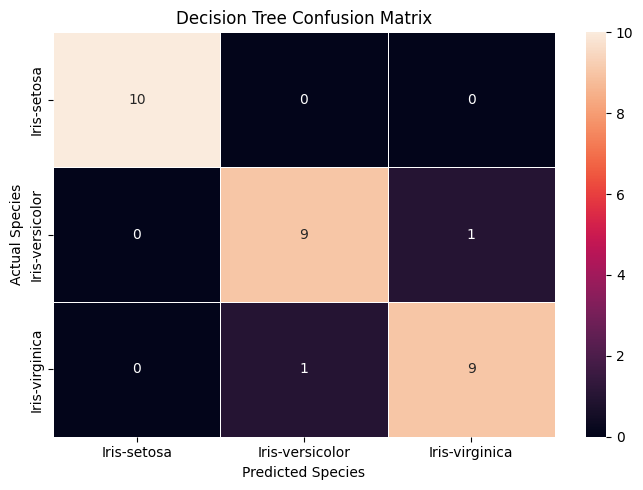

Plot saved successfully!
Location: d:\system tron intership\data science inter\Iris_Flower_Classification_Week_4\results\06_decision_tree_confusion_matrix.png


In [40]:
# Decision Tree confusion matrix
dt_cm = confusion_matrix(y_test, dt_predictions)

plt.figure(figsize=(7, 5))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")

plt.tight_layout()

dt_cm_file = results_path / "06_decision_tree_confusion_matrix.png"

plt.savefig(
    dt_cm_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Plot saved successfully!")
print("Location:", dt_cm_file)

Random Forest Confusion Matrix

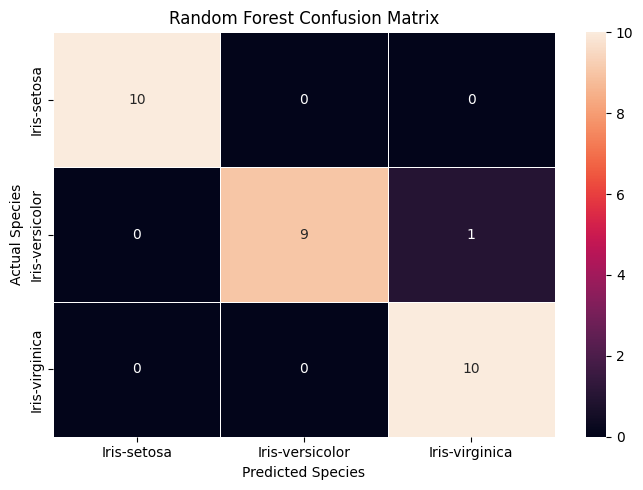

Plot saved successfully!
Location: d:\system tron intership\data science inter\Iris_Flower_Classification_Week_4\results\07_random_forest_confusion_matrix.png


In [41]:
# Random Forest confusion matrix
rf_cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(7, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")

plt.tight_layout()

rf_cm_file = results_path / "07_random_forest_confusion_matrix.png"

plt.savefig(
    rf_cm_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Plot saved successfully!")
print("Location:", rf_cm_file)

KNN Confusion Matrix

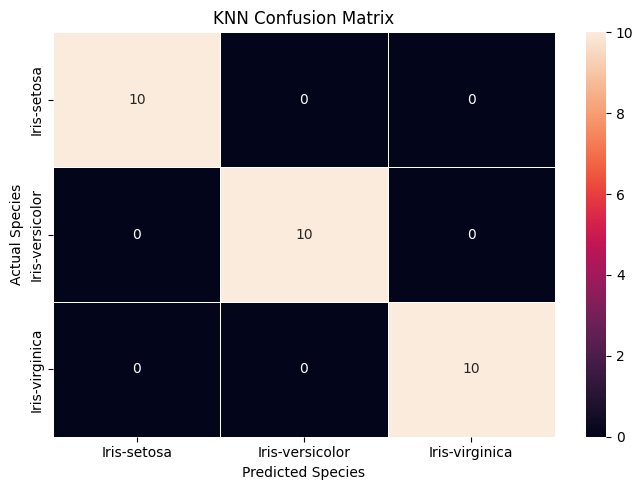

Plot saved successfully!
Location: d:\system tron intership\data science inter\Iris_Flower_Classification_Week_4\results\08_knn_confusion_matrix.png


In [42]:
# KNN confusion matrix
knn_cm = confusion_matrix(y_test, knn_predictions)

plt.figure(figsize=(7, 5))

sns.heatmap(
    knn_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")

plt.tight_layout()

knn_cm_file = results_path / "08_knn_confusion_matrix.png"

plt.savefig(
    knn_cm_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Plot saved successfully!")
print("Location:", knn_cm_file)

## 10. Model Comparison & Best Model Selection

The performance of the three trained classification models is compared using accuracy, precision, recall, and F1-score.

The model with the strongest overall performance is selected as the final classification model.

F1-score is considered alongside accuracy because it provides a balanced measure of precision and recall.

In [43]:
from pathlib import Path

# Create models directory
models_path = project_root / "models"
models_path.mkdir(parents=True, exist_ok=True)

print("Models folder created successfully!")
print("Location:", models_path)

Models folder created successfully!
Location: d:\system tron intership\data science inter\Iris_Flower_Classification_Week_4\models


### 10.1 Model Performance Comparison

The evaluation metrics of the Decision Tree, Random Forest, and KNN models are compared to identify the best-performing classifier.

In [44]:
# Display model comparison
print("Model Performance Comparison")
print("=" * 70)

evaluation_df

Model Performance Comparison


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.933333,0.933333,0.933333,0.933333
1,Random Forest,0.966667,0.969697,0.966667,0.966583
2,KNN,1.000000,1.000000,1.000000,1.000000


### 10.2 Best Model Selection

The model with the highest F1-score is selected as the final classification model.

Based on the evaluation results, K-Nearest Neighbors (KNN) achieved the highest performance across accuracy, precision, recall, and F1-score.

In [45]:
# Select model with highest F1-score
best_model_name = evaluation_df.loc[
    evaluation_df["F1-Score"].idxmax(),
    "Model"
]

best_f1_score = evaluation_df["F1-Score"].max()

print("Best Model:", best_model_name)
print("Best F1-Score:", round(best_f1_score, 4))

Best Model: KNN
Best F1-Score: 1.0


### 10.3 Save Model Comparison Results

The model evaluation results are saved as a CSV file in the `results` directory.

This file can be used for documentation, reporting, and further analysis.

In [46]:
# Save model comparison results
comparison_file = models_path / "model_comparison.csv"

evaluation_df.to_csv(
    comparison_file,
    index=False
)

print("Model comparison saved successfully!")
print("Location:", comparison_file)

Model comparison saved successfully!
Location: d:\system tron intership\data science inter\Iris_Flower_Classification_Week_4\models\model_comparison.csv


## 11. New Iris Flower Prediction

The best-performing machine learning model, K-Nearest Neighbors (KNN), is used to classify a new Iris flower.

The prediction is based on four measurements:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

The numerical prediction generated by the model is converted back into the corresponding Iris species name.

### 11.1 Predict a New Iris Flower

A new Iris flower sample is created using sepal and petal measurements.

The trained KNN model predicts the species of the new flower based on its measurements.

In [47]:
# New Iris flower measurements
new_flower = pd.DataFrame(
    [[5.9, 3.0, 5.1, 1.8]],
    columns=[
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ]
)

# Predict using the trained KNN model
new_prediction = knn.predict(new_flower)

# Convert numerical prediction to species name
predicted_species = label_encoder.inverse_transform(new_prediction)

print("New Flower Measurements:")
display(new_flower)

print("Predicted Species:", predicted_species[0])

New Flower Measurements:


,sepal_length,sepal_width,petal_length,petal_width
0,5.9,3.0,5.1,1.8


Predicted Species: Iris-virginica


### 11.2 Prediction Probability

The probability of the new flower belonging to each Iris species is calculated using the trained KNN model.

This provides additional information about the model's confidence in its prediction.

In [48]:
# Get prediction probabilities
prediction_probabilities = knn.predict_proba(new_flower)

# Create probability table
probability_df = pd.DataFrame(
    prediction_probabilities,
    columns=label_encoder.classes_
)

print("Prediction Probabilities:")
display(probability_df)

print(
    "Predicted Species:",
    predicted_species[0]
)

Prediction Probabilities:


,Iris-setosa,Iris-versicolor,Iris-virginica
0,0.0,0.4,0.6


Predicted Species: Iris-virginica


### 11.3 Save Prediction Result

The new Iris flower measurements and the predicted species are saved as a CSV file in the `results` directory.

This provides a reproducible record of the model's prediction.

In [49]:
# Add prediction to the new flower data
prediction_result = new_flower.copy()

prediction_result["predicted_species"] = predicted_species[0]

# Save prediction result in models folder
prediction_file = models_path / "new_flower_prediction.csv"

prediction_result.to_csv(
    prediction_file,
    index=False
)

print("Prediction result saved successfully!")
print("Location:", prediction_file)

display(prediction_result)

Prediction result saved successfully!
Location: d:\system tron intership\data science inter\Iris_Flower_Classification_Week_4\models\new_flower_prediction.csv


,sepal_length,sepal_width,petal_length,petal_width,predicted_species
0,5.9,3.0,5.1,1.8,Iris-virginica


## 12. Save the Final Machine Learning Model

The best-performing K-Nearest Neighbors (KNN) model is saved for future use.

Saving the trained model allows predictions to be made later without retraining the model from the beginning.

The trained model is stored in the `models` directory.

In [50]:
import joblib

# Save the trained KNN model
knn_model_file = models_path / "iris_knn_model.pkl"

joblib.dump(
    knn,
    knn_model_file
)

print("KNN model saved successfully!")
print("Location:", knn_model_file)

KNN model saved successfully!
Location: d:\system tron intership\data science inter\Iris_Flower_Classification_Week_4\models\iris_knn_model.pkl


### 12.2 Verify the Saved Model

The saved KNN model is loaded from the `models` directory and used to make a prediction.

This verifies that the trained model has been successfully saved and can be reused.

In [51]:
# Load the saved KNN model
loaded_knn = joblib.load(knn_model_file)

# Make prediction using loaded model
loaded_prediction = loaded_knn.predict(new_flower)

# Convert prediction to species name
loaded_species = label_encoder.inverse_transform(loaded_prediction)

print("Saved model loaded successfully!")
print("Prediction from saved model:", loaded_species[0])

Saved model loaded successfully!
Prediction from saved model: Iris-virginica


## 13. Final Model Summary

The Iris Flower Classification project successfully developed and evaluated multiple supervised machine learning classification models.

### Dataset

- Dataset: Iris Flower Dataset provided by SystemTron
- Original records: 150
- Features: 4 numerical measurements
- Target: Species
- Species:
  - Iris-setosa
  - Iris-versicolor
  - Iris-virginica

### Data Preparation

- Checked dataset structure and data types
- Checked for missing values
- No missing values were found
- Identified and removed 3 duplicate records
- Final dataset size: 147 records
- Encoded the target species into numerical labels
- Split the dataset into 80% training and 20% testing data

### Machine Learning Models

Three classification algorithms were trained:

1. Decision Tree
2. Random Forest
3. K-Nearest Neighbors (KNN)

### Model Performance

| Model | Accuracy | Precision | Recall | F1-Score |
|---|---:|---:|---:|---:|
| Decision Tree | 93.33% | 93.33% | 93.33% | 93.33% |
| Random Forest | 96.67% | 96.97% | 96.67% | 96.66% |
| KNN | 100.00% | 100.00% | 100.00% | 100.00% |

### Best Model

K-Nearest Neighbors (KNN) achieved the highest performance on the test dataset with:

- Accuracy: 100%
- Precision: 100%
- Recall: 100%
- F1-Score: 100%

Therefore, KNN was selected as the final model for Iris flower classification.

## 13.1 Project Conclusion

The Iris Flower Classification project successfully demonstrated the use of supervised machine learning to classify Iris flowers into Setosa, Versicolor, and Virginica species based on their sepal and petal measurements.

The project followed a complete Data Science workflow, including data loading, data understanding, data cleaning, exploratory data analysis, feature preparation, train-test splitting, model training, model evaluation, and prediction.

Three classification algorithms were evaluated: Decision Tree, Random Forest, and K-Nearest Neighbors.

Among the evaluated models, K-Nearest Neighbors achieved the highest performance on the held-out test dataset, with 100% accuracy, precision, recall, and F1-score.

The trained KNN model was saved for future predictions, demonstrating how a machine learning model can be developed, evaluated, and reused for new Iris flower measurements.

Overall, the project successfully fulfills the objective of developing a machine learning model capable of classifying Iris flowers based on their sepal and petal measurements.

## 13.2 Future Improvements

The project can be further improved by:

- Performing hyperparameter tuning for the classification models
- Using cross-validation to obtain more robust performance estimates
- Testing additional classification algorithms such as Logistic Regression and Support Vector Machines
- Creating an interactive prediction application
- Deploying the trained model as a web application or API
- Testing the model on additional Iris flower samples